# Homework -2

### By Wasim Raja Mondal

### Part 1: Q3.

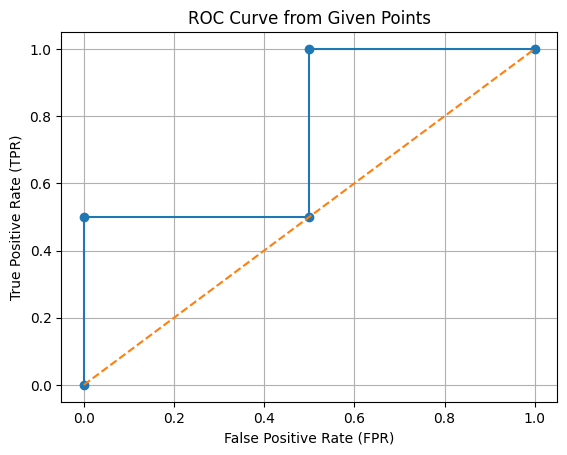

In [1]:
import matplotlib.pyplot as plt

# ROC points
fpr = [0, 0, 0.5, 0.5, 1]
tpr = [0, 0.5, 0.5, 1, 1]

plt.figure()

# ROC curve
plt.plot(fpr, tpr, marker='o')

# Random classifier line
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve from Given Points")

plt.grid(True)
plt.show()

## Logistic Regression without regularization

### 1. Importing the libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 2. Importing the dataset

In [3]:
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()


### Inspect Dataset Information

In [4]:
print(data.feature_names)
print(data.target_names)
print(data.DESCR)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']
.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    -

### Convert to Pandas DataFrame

In [5]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
X = df.drop(['target'], axis=1)
y = df['target']

In [8]:
X.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [9]:
y.head(20)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    1
Name: target, dtype: int64

In [10]:
y.describe()

count    569.000000
mean       0.627417
std        0.483918
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

### Splitting the dataset into the Training set and Test set

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [12]:
print(X_train)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
293       11.850         17.46           75.54      432.7          0.08372   
332       11.220         19.86           71.94      387.3          0.10540   
565       20.130         28.25          131.20     1261.0          0.09780   
278       13.590         17.84           86.24      572.3          0.07948   
489       16.690         20.20          107.10      857.6          0.07497   
..           ...           ...             ...        ...              ...   
277       18.810         19.98          120.90     1102.0          0.08923   
9         12.460         24.04           83.97      475.9          0.11860   
359        9.436         18.32           59.82      278.6          0.10090   
192        9.720         18.22           60.73      288.1          0.06950   
559       11.510         23.93           74.52      403.5          0.09261   

     mean compactness  mean concavity  mean concave points  mea

In [13]:
print(y_train)

293    1
332    1
565    0
278    1
489    0
      ..
277    0
9      0
359    1
192    1
559    1
Name: target, Length: 426, dtype: int64


In [14]:
print(X_test)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
512        13.40         20.52           88.64      556.7          0.11060   
457        13.21         25.25           84.10      537.9          0.08791   
439        14.02         15.66           89.59      606.5          0.07966   
298        14.26         18.17           91.22      633.1          0.06576   
37         13.03         18.42           82.61      523.8          0.08983   
..           ...           ...             ...        ...              ...   
236        23.21         26.97          153.50     1670.0          0.09509   
113        10.51         20.19           68.64      334.2          0.11220   
527        12.34         12.27           78.94      468.5          0.09003   
76         13.53         10.94           87.91      559.2          0.12910   
162        19.59         18.15          130.70     1214.0          0.11200   

     mean compactness  mean concavity  mean concave points  mea

In [15]:
print(y_test)

512    0
457    1
439    1
298    1
37     1
      ..
236    0
113    1
527    1
76     1
162    0
Name: target, Length: 143, dtype: int64


### Training the Logistic Regression model on the Training set

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Predicting a new result

In [17]:
print(model.predict(X_test[:1]))   # predict first test sample (shape 1x30)

[0]


### Predicting the Test set results

In [18]:
y_pred = model.predict(X_test)
p_test = model.predict_proba(X_test)  # probabilities one column per class
print("First 10 probabilities:\n", p_test[:10])

First 10 probabilities:
 [[9.98648594e-01 1.35140551e-03]
 [3.97049107e-02 9.60295089e-01]
 [1.30747928e-03 9.98692521e-01]
 [1.24088419e-02 9.87591158e-01]
 [2.44097465e-04 9.99755903e-01]
 [4.46535523e-03 9.95534645e-01]
 [1.12358878e-04 9.99887641e-01]
 [1.81602522e-03 9.98183975e-01]
 [9.80602662e-05 9.99901940e-01]
 [1.75676970e-06 9.99998243e-01]]


### Predicted vs True table

In [19]:
results = pd.DataFrame({
    "Prob_Class0": p_test[:, 0],
    "Prob_Class1": p_test[:, 1],
    "Predicted": y_pred,
    "Actual": y_test
})

print("\nPredicted vs True (first 10 rows):")
print(results.head(10))


Predicted vs True (first 10 rows):
     Prob_Class0  Prob_Class1  Predicted  Actual
512     0.998649     0.001351          0       0
457     0.039705     0.960295          1       1
439     0.001307     0.998693          1       1
298     0.012409     0.987591          1       1
37      0.000244     0.999756          1       1
515     0.004465     0.995535          1       1
382     0.000112     0.999888          1       1
310     0.001816     0.998184          1       1
538     0.000098     0.999902          1       1
345     0.000002     0.999998          1       1


### The Confusion Matrix

In [20]:
print("\nConfusion Matrix:");
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nAccuracy:")
accuracy_score(y_test, y_pred)


Confusion Matrix:
[[50  3]
 [ 3 87]]

Accuracy:


0.958041958041958

### Classification report

In [21]:
print("\nClassification Report:\n")
from sklearn.metrics import log_loss, classification_report
print(classification_report(y_test, y_pred, target_names=data.target_names))


Classification Report:

              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        53
      benign       0.97      0.97      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



### ROC curve + AUROC

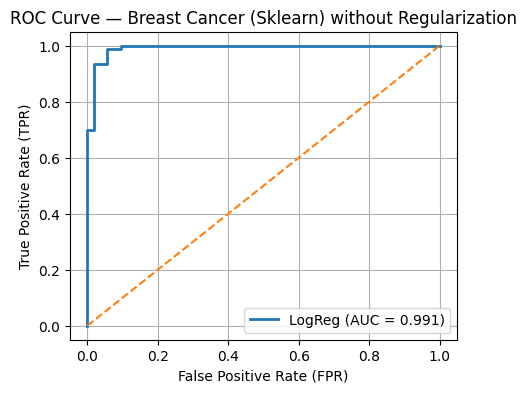

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob_pos = p_test[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_pos)
auc = roc_auc_score(y_test, y_prob_pos)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, linewidth=2, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve — Breast Cancer (Sklearn) without Regularization")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

### PR curve + AUPRC

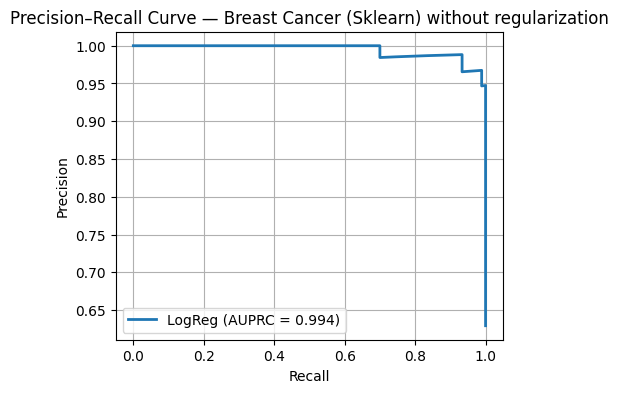

First 10 PR points (recall, precision):
[(np.float64(1.0), np.float64(0.6293706293706294)), (np.float64(1.0), np.float64(0.6338028169014085)), (np.float64(1.0), np.float64(0.6382978723404256)), (np.float64(1.0), np.float64(0.6428571428571429)), (np.float64(1.0), np.float64(0.6474820143884892)), (np.float64(1.0), np.float64(0.6521739130434783)), (np.float64(1.0), np.float64(0.656934306569343)), (np.float64(1.0), np.float64(0.6617647058823529)), (np.float64(1.0), np.float64(0.6666666666666666)), (np.float64(1.0), np.float64(0.6716417910447762))]

AUPRC (Average Precision): 0.9944312638675457


In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probability of the positive class (class = 1)
y_prob_pos = p_test[:, 1]   # or: y_prob_pos = model.predict_proba(X_test)[:, 1]

# PR curve points
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_pos)

# AUPRC (Average Precision)
auprc = average_precision_score(y_test, y_prob_pos)

# Plot PR curve
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, linewidth=2, label=f"LogReg (AUPRC = {auprc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Breast Cancer (Sklearn) without regularization")
plt.grid(True)
plt.legend(loc="lower left")
plt.show()

# Optional: print first few points
print("First 10 PR points (recall, precision):")
print(list(zip(recall[:10], precision[:10])))

print("\nAUPRC (Average Precision):", auprc)

### Model with Regularization

In [24]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# -----------------------------
# 1) Load + split
# -----------------------------
data = load_breast_cancer()
X, y = data.data, data.target   # 0=malignant, 1=benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 2) Train multiple L2 models
#    LogisticRegression uses L2 by default (penalty="l2")
#    Regularization strength is controlled by C:
#      smaller C => stronger regularization
#      larger C  => weaker regularization
# -----------------------------
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

rows = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",   # good for binary + L2
            max_iter=5000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # metrics
    rows.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
    })

results = pd.DataFrame(rows).sort_values("C")

print(results.to_string(index=False))

      C  Accuracy  Precision   Recall       F1  ROC_AUC    AUPRC
  0.001  0.938596   0.957746 0.944444 0.951049 0.990741 0.994654
  0.010  0.956140   0.958904 0.972222 0.965517 0.995040 0.997140
  0.100  0.982456   0.986111 0.986111 0.986111 0.996032 0.997645
  1.000  0.982456   0.986111 0.986111 0.986111 0.995701 0.997297
 10.000  0.964912   0.972222 0.972222 0.972222 0.993386 0.995726
100.000  0.947368   0.971429 0.944444 0.957746 0.986111 0.990788


Evaluation Metrics
------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861

Full Classification Report
--------------------------
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



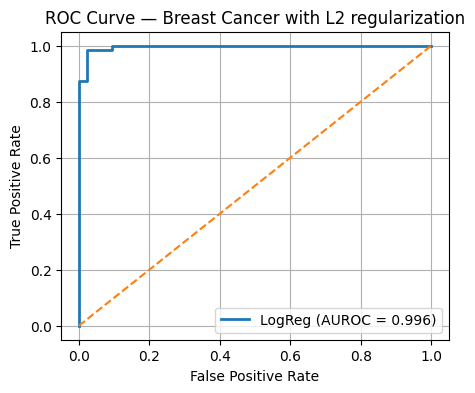

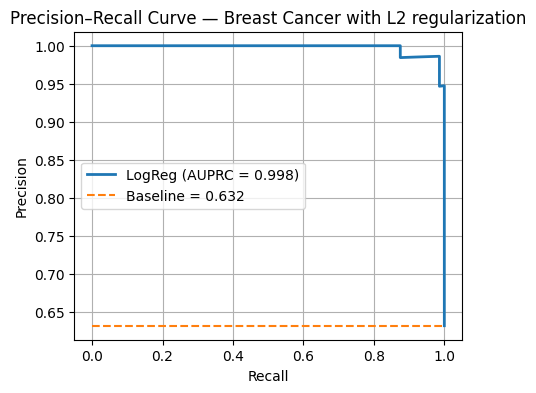

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)

# -------------------------
# Train final model
# -------------------------
best_C = 0.1

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=best_C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

# -------------------------
# Predictions
# -------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# -------------------------
# Basic metrics
# -------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics")
print("------------------")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# -------------------------
# Full Classification Report
# -------------------------
print("\nFull Classification Report")
print("--------------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

# -------------------------
# ROC Curve + AUROC
# -------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auroc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, linewidth=2, label=f"LogReg (AUROC = {auroc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Breast Cancer with L2 regularization")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# PR Curve + AUPRC
# -------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, linewidth=2, label=f"LogReg (AUPRC = {auprc:.3f})")

baseline = y_test.mean()
plt.plot([0,1], [baseline, baseline], linestyle="--", label=f"Baseline = {baseline:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Breast Cancer with L2 regularization")
plt.grid(True)
plt.legend()
plt.show()

### Part 4: Multiclass Classification (Softmax)

### import wine dataset

In [26]:
from sklearn.datasets import load_wine
import pandas as pd

# Load dataset
wine = load_wine()

# Features and target
X = wine.data
y = wine.target

# Feature names and class names
feature_names = wine.feature_names
target_names = wine.target_names

print("Feature names:")
print(feature_names)

print("\nClass labels:")
print(target_names)

print("\nShape of dataset:")
print(X.shape)

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class labels:
['class_0' 'class_1' 'class_2']

Shape of dataset:
(178, 13)


### convert this dataset to pandas dataframe

In [27]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

### checking for class distribution

In [28]:
import numpy as np

print("Class distribution:", np.bincount(y))

Class distribution: [59 71 48]


- Meaning Class 0 has 59 samples, Class 1 has 71 samples and Class 2 has 48 samples

### Train, Test split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train a Softmax model

In [30]:
import warnings

# Hide only sklearn's transition warnings (keeps other important warnings visible)
warnings.filterwarnings(
    "ignore",
    message=".*'penalty' was deprecated.*",
    category=FutureWarning,
    module=r"sklearn\.linear_model\._logistic"
)

warnings.filterwarnings(
    "ignore",
    message=".*Setting penalty=None will ignore the C and l1_ratio parameters.*",
    category=UserWarning,
    module=r"sklearn\.linear_model\._logistic"
)

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=5000))
])

model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Prediction

In [32]:
y_pred = model.predict(X_test)
probs = model.predict_proba(X_test)

print("Predicted classes:", y_pred[:10])
for i in range(6):
    print(f"\nClass probabilities (sample {i+1}):")
    print(np.round(probs[i],6))

Predicted classes: [0 1 0 1 1 0 0 1 1 2]

Class probabilities (sample 1):
[9.99671e-01 3.07000e-04 2.30000e-05]

Class probabilities (sample 2):
[0.007051 0.540423 0.452526]

Class probabilities (sample 3):
[9.920e-01 7.664e-03 3.360e-04]

Class probabilities (sample 4):
[0.289967 0.707467 0.002565]

Class probabilities (sample 5):
[0.033032 0.962313 0.004655]

Class probabilities (sample 6):
[9.99166e-01 7.70000e-04 6.30000e-05]


In [33]:
model.classes_

array([0, 1, 2])

### Accuracy, Macro F1, Micro F1

In [34]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Macro F1
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Micro F1
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Accuracy :", round(accuracy,4))
print("Macro F1 :", round(macro_f1,4))
print("Micro F1 :", round(micro_f1,4))

Accuracy : 0.9722
Macro F1 : 0.971
Micro F1 : 0.9722


### k-fold cross validation

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

   Accuracy  Macro F1  Micro F1
0  0.972222  0.971781  0.972222
1  0.972222  0.971781  0.972222
2  0.972222  0.970962  0.972222
3  1.000000  1.000000  1.000000
4  1.000000  1.000000  1.000000


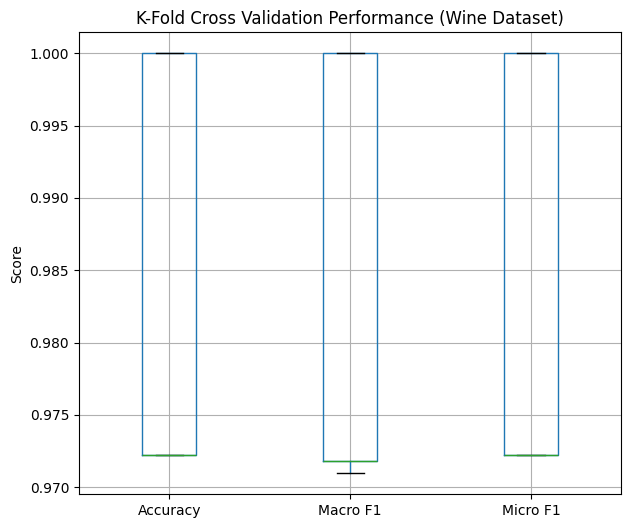

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Pipeline model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(multi_class="multinomial",
                               solver="lbfgs",
                               max_iter=5000))
])

# Stratified 5-fold cross validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "micro_f1": "f1_micro"
}

results = cross_validate(model, X, y, cv=kfold, scoring=scoring)

# Convert results to DataFrame
df_results = pd.DataFrame({
    "Accuracy": results["test_accuracy"],
    "Macro F1": results["test_macro_f1"],
    "Micro F1": results["test_micro_f1"]
})

print(df_results)

# Boxplot visualization
plt.figure(figsize=(7,6))
df_results.boxplot()

plt.title("K-Fold Cross Validation Performance (Wine Dataset)")
plt.ylabel("Score")
plt.grid(True)
plt.show()

### Cross validation for Breast Cancer dataset

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Pipeline (scaling + logistic regression)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

# 5-fold stratified cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute cross-validation accuracy
scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

# Mean and standard deviation
mean_acc = np.mean(scores)
std_acc = np.std(scores)

print("Accuracy scores for each fold:", scores)
print(f"\nMean Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation: {std_acc:.4f}")
print(f"\nResult: {mean_acc:.4f} ({std_acc:.4f})")

Accuracy scores for each fold: [0.97368421 0.94736842 0.96491228 0.99122807 0.99115044]

Mean Accuracy: 0.9737
Standard Deviation: 0.0166

Result: 0.9737 (0.0166)


### Generate learning curve

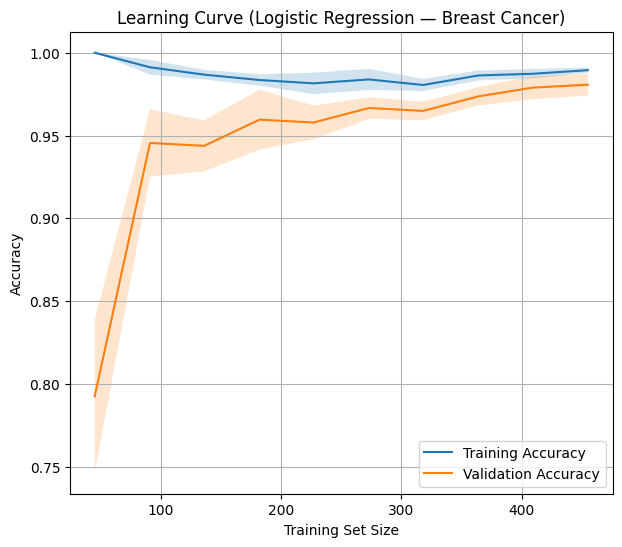

In [37]:
from sklearn.model_selection import learning_curve

# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(7,6))

plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Logistic Regression — Breast Cancer)")
plt.legend()
plt.grid(True)

plt.show()